In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: wrong dep version loaded (2), include_dependency fhash change (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x9b807a5393ae283c, 0x54d6cb411c5973ca, 0xa0f75e33ba9eff4b, 0xe68b630b8e2d24cb, 0x89f55c3c833fa833, 0xb2cd1089852dec54, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 30.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=0.015), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=3.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(OscillationC

In [4]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [5]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [6]:
p = Newtrinos.get_params(experiments)

(N = 30.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [7]:
using Setfield

In [8]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 30.0, m₀ = 0.10926719379341292, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [9]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [10]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58880.28163986557
 61584.12571273542
 56531.294099530074
 69655.82721896615
 77699.16783997149
 86511.83895659035
 87298.85359380719
 82633.25755896543
 78443.3502862713
 73202.63484841536
 66066.61385729659
 59830.582720965205
 53825.73343758047
 48954.73539453612
 44647.830512294386
 39827.57261815098
 33519.08252291036
 34431.44003395478
 25260.310227331254
 19827.51055892042
 14663.59292816541
  9864.542384028266
  6413.291323522961
  6728.206168476502
  3691.293522064026
 17215.954241636704

In [11]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58771.16039017936
 61524.988037932606
 56628.80234996476
 69617.39028169877
 77648.33973013169
 86653.78340305109
 87243.74684713915
 82708.75142121529
 78499.6901556449
 73233.24464392426
 66079.11626908577
 59779.38069772175
 53859.63506659755
 49034.52650096028
 44572.26531821488
 39834.41830630379
 33501.33026761147
 34452.060865126274
 25321.721849962
 19795.972612197696
 14675.763323640589
  9874.53869952408
  6398.277200249657
  6727.525309877251
  3691.1784414076483
 17217.761455272594

In [12]:
using CairoMakie

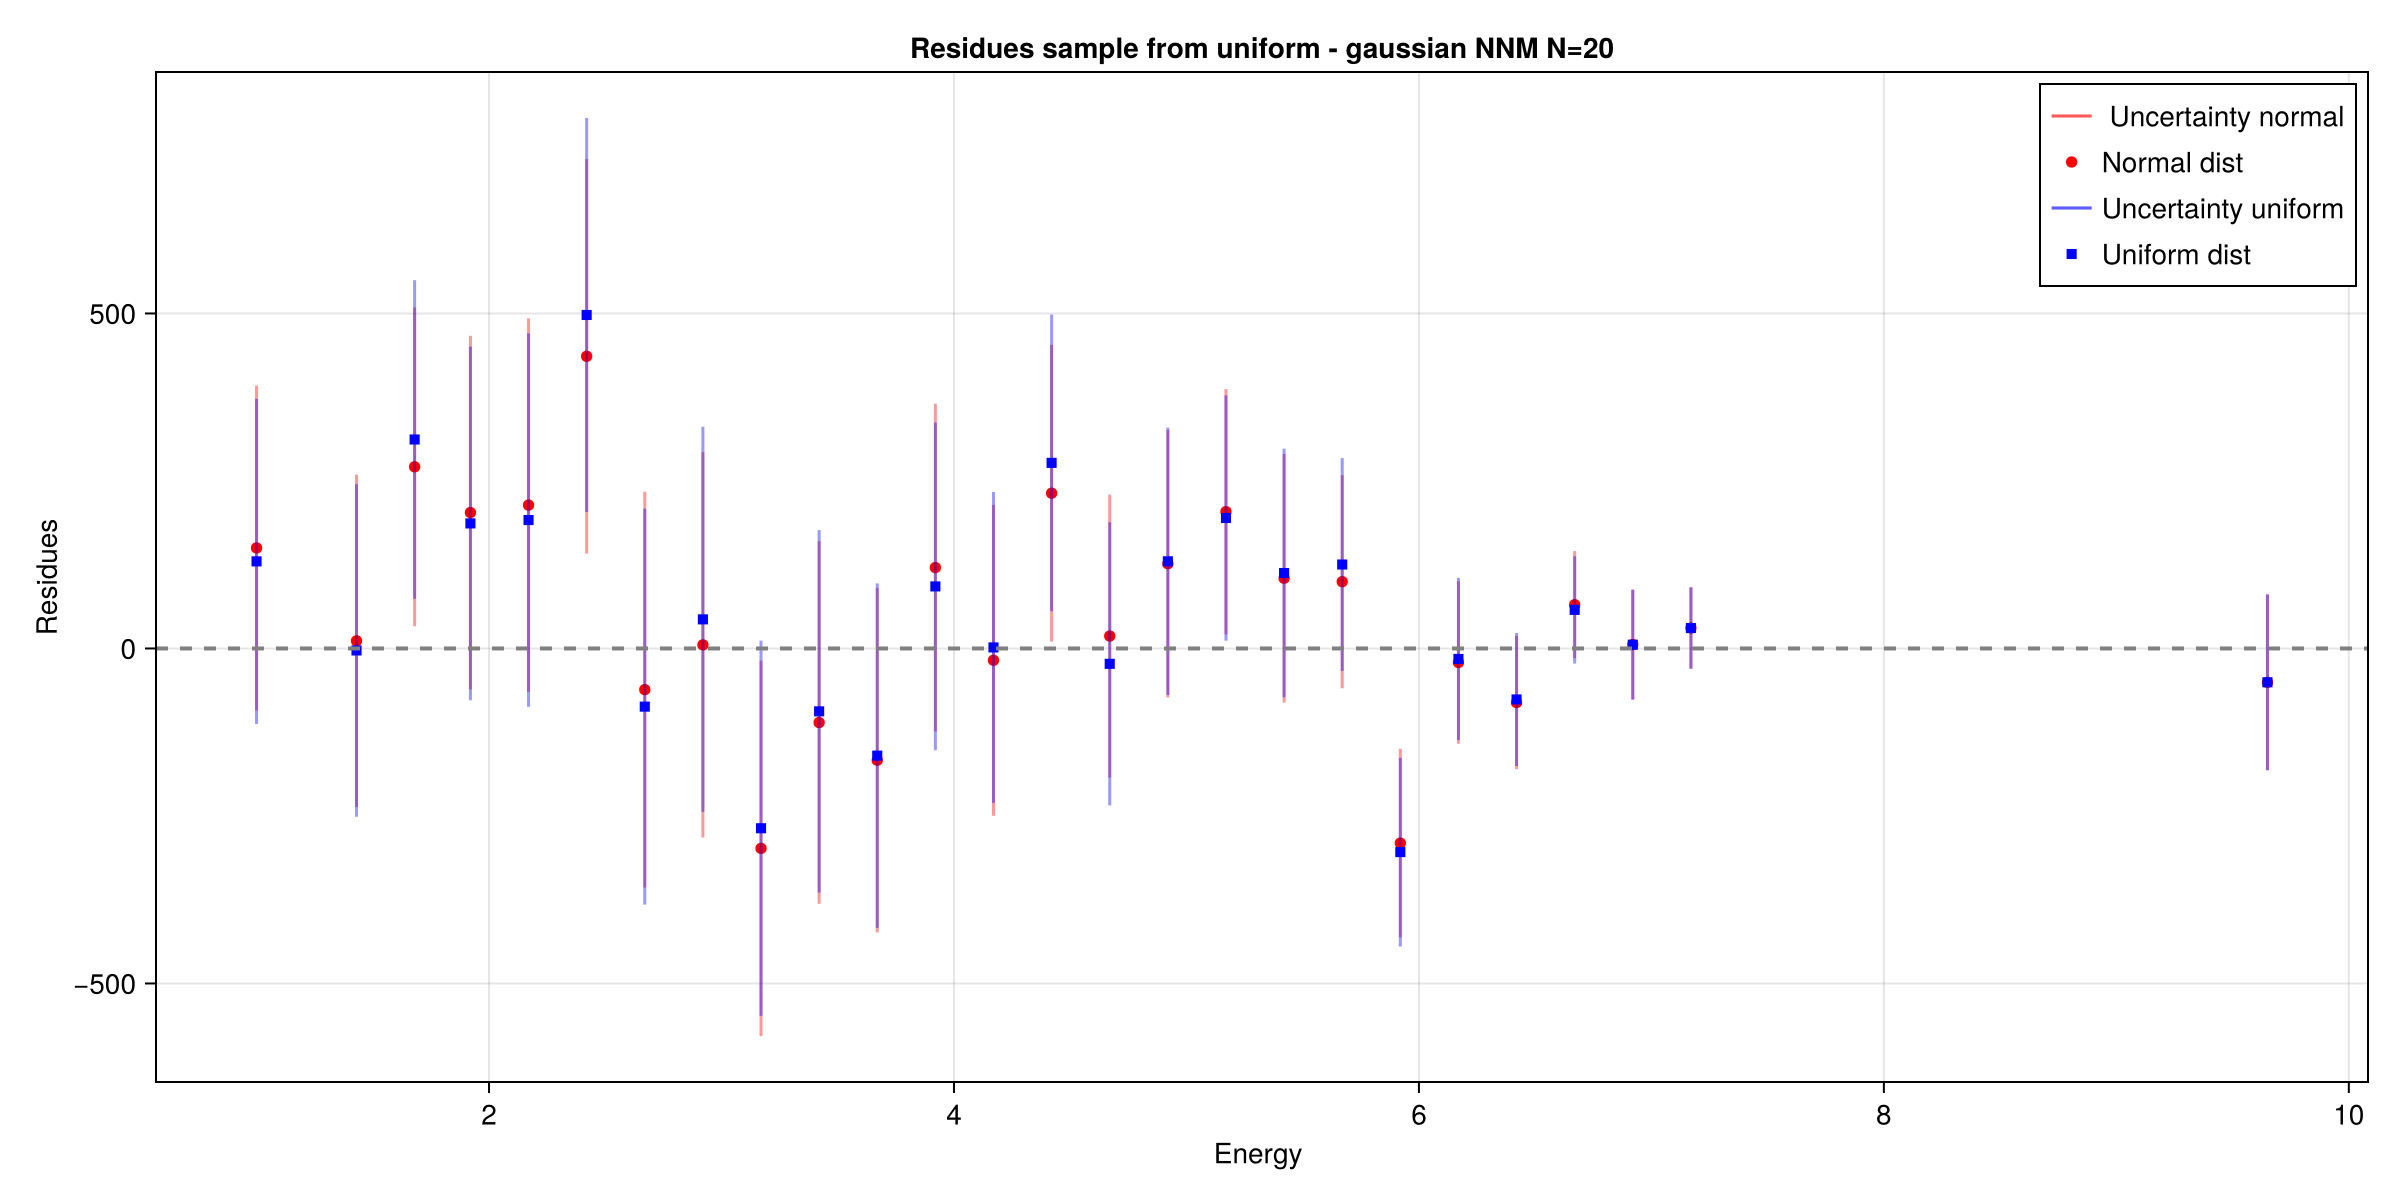

CairoMakie.Screen{IMAGE}


In [13]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=20")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [14]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [15]:

using ProgressMeter
using MeasureBase

In [22]:
function random_sampling(physics, experiments, p)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/10000000000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm

      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [23]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:10:17


([-168.53138419068065, -168.32101497302742, -168.43304948126044, -168.3956949301182, -168.74752281739953, -168.32121375978832, -168.64867743948693, -168.7540922269603, -168.34171991537048, -168.33962915537288  …  -168.50474396624327, -168.80856163893623, -168.41510745161068, -168.1805374410506, -168.252408583346, -168.27544935037056, -168.15862906252494, -168.73658194362048, -168.41797865586943, -168.9545369234908], [-169.00349951661713, -168.62474525668583, -168.73188696564907, -168.51266199241468, -168.75283188762407, -168.78152668470872, -168.71127041684872, -168.78686575183485, -168.53049501928498, -168.93741239442798  …  -168.78719750815966, -168.9154288213666, -168.5883776608531, -168.97638072799387, -168.9304654286758, -168.9317264038001, -168.98521005708386, -168.9777044087479, -168.94978826065088, -168.95996466809748])

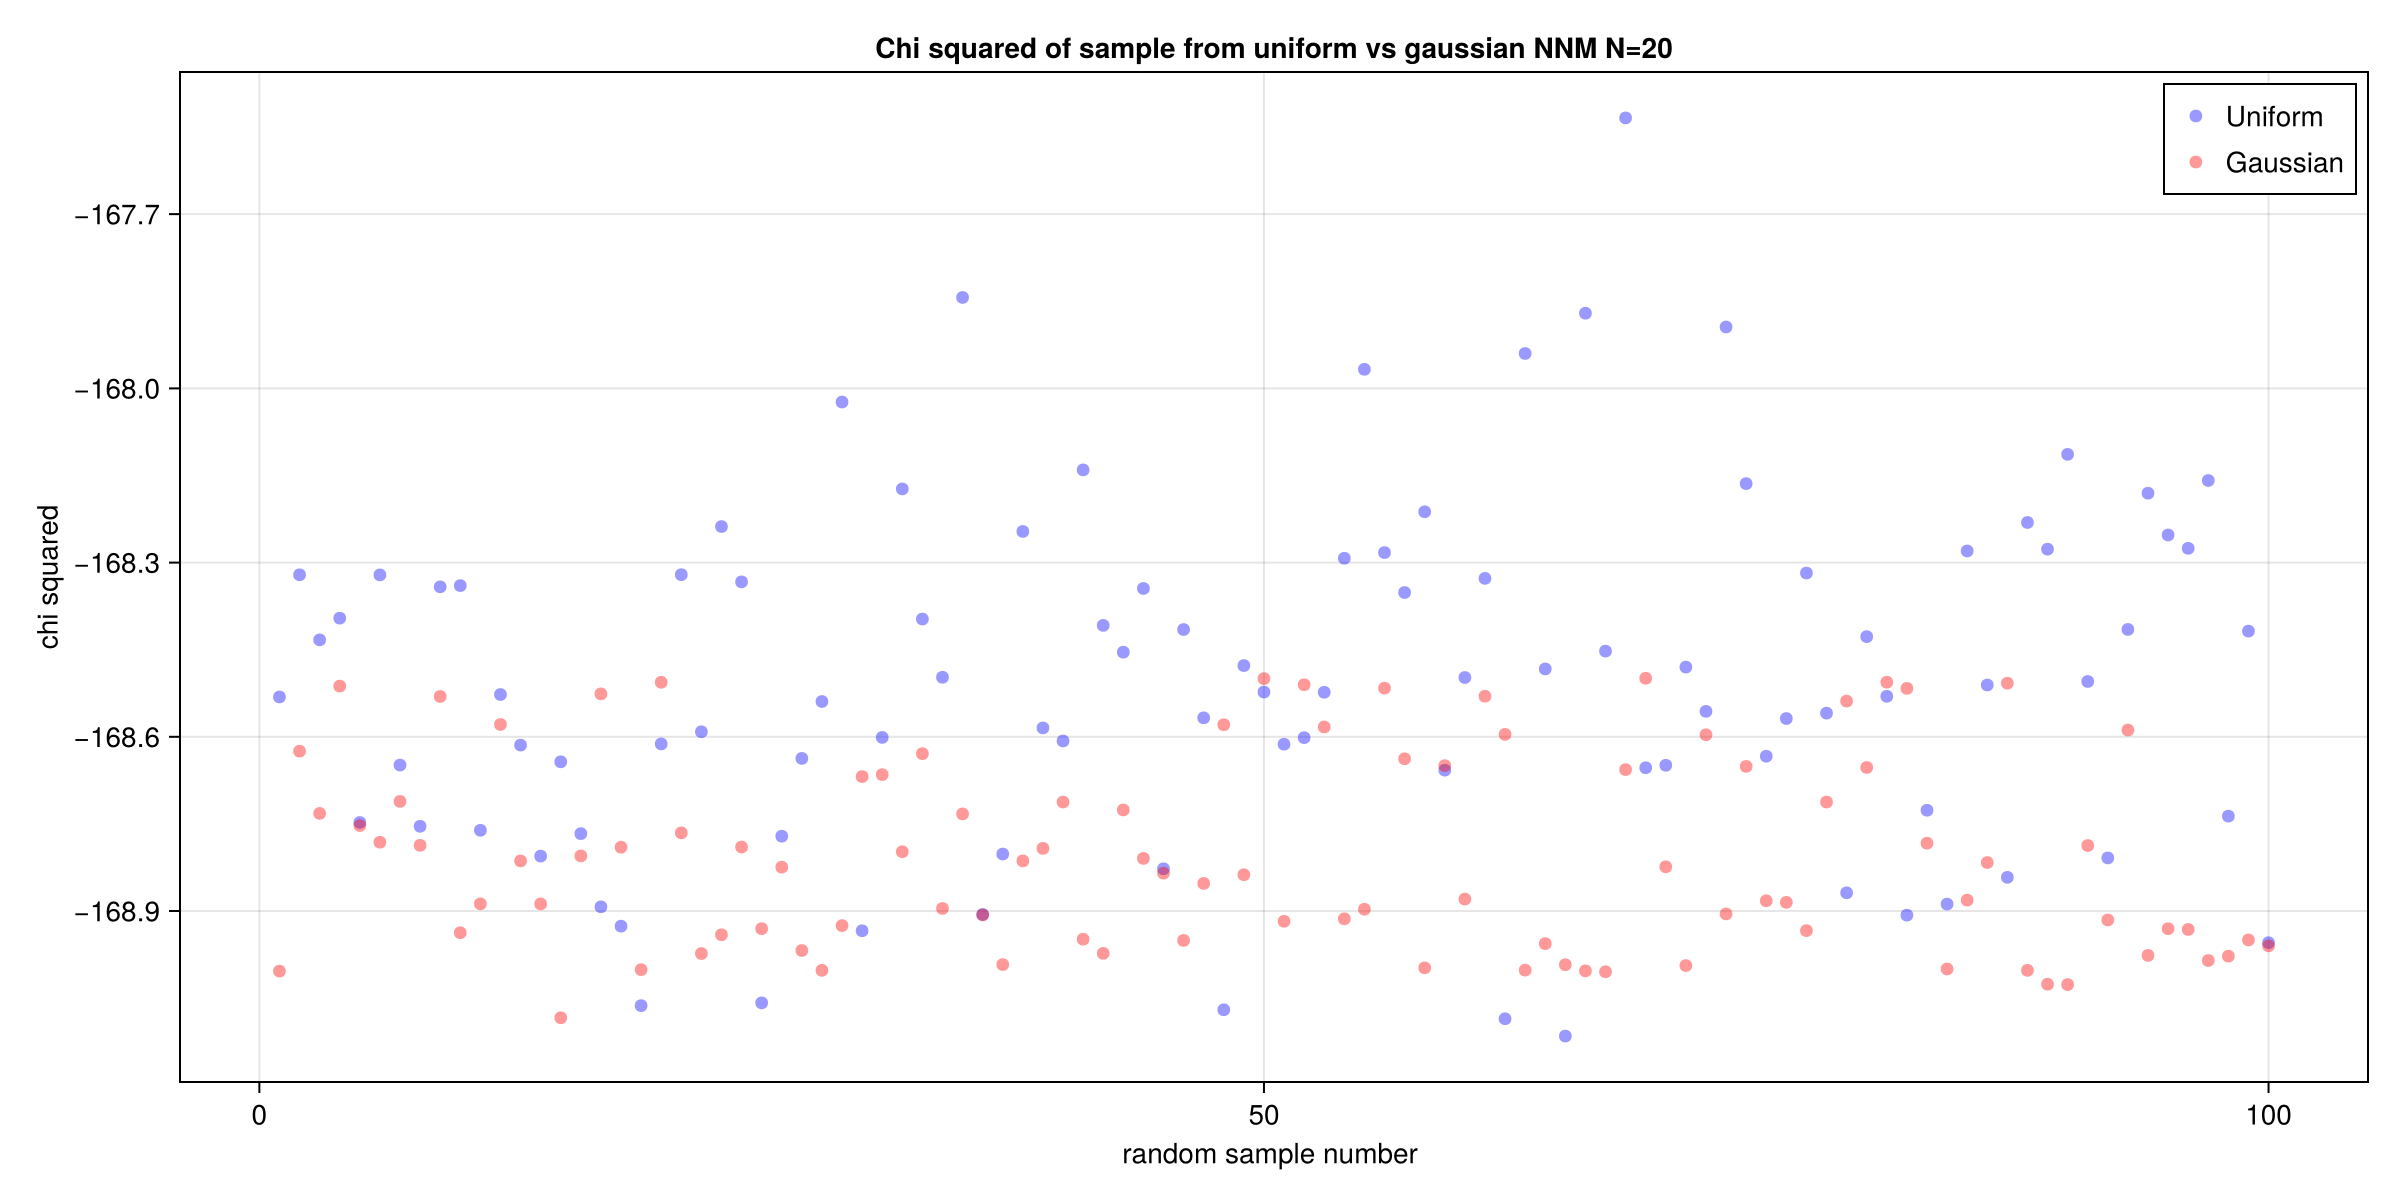

CairoMakie.Screen{IMAGE}


In [24]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "chi squared", 
    title = "Chi squared of sample from uniform vs gaussian NNM N=20")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.4), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.4), label = "Gaussian")

   
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N20_m0=0.1_chi.png", fig)